In [54]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import EfficientSU2, RealAmplitudes
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit_ibm_runtime.fake_provider.fake_backend import FakeBackendV2
from qiskit.providers import Backend

## Qubit count scaling

In [16]:
def fcc_no_slack(n: int) -> int:
    return int(4 * n - 10 + 1 - 3 * n / 2 + n ** 2 / 2)

def fcc_slack(n: int) -> int:
    num_slack_qubits = 0
    for i in range(n - 3):
        for j in range(i + 3, n):
            num_slack_qubits += np.ceil(2 * np.log2(j - i))
    return int(4 * n - 10 + 1 - 3 * n / 2 + n ** 2 / 2 + num_slack_qubits)

def tetrahedral(n: int) -> int:
    return int(2 * (n - 3) - 1 + ((n - 4) ** 2 - np.mod(n - 6, 2) ** 2) / 4)

In [18]:
for n in range(5, 11):
    print(f"n = {n}")
    print(f"tetrahedral = {tetrahedral(n)}")
    print(f"fcc_no_slack = {fcc_no_slack(n)}")
    print(f"fcc_slack = {fcc_slack(n)}")
    print()

n = 5
tetrahedral = 3
fcc_no_slack = 16
fcc_slack = 28

n = 6
tetrahedral = 6
fcc_no_slack = 24
fcc_slack = 49

n = 7
tetrahedral = 9
fcc_no_slack = 33
fcc_slack = 77

n = 8
tetrahedral = 13
fcc_no_slack = 43
fcc_slack = 112

n = 9
tetrahedral = 17
fcc_no_slack = 54
fcc_slack = 154

n = 10
tetrahedral = 22
fcc_no_slack = 66
fcc_slack = 204



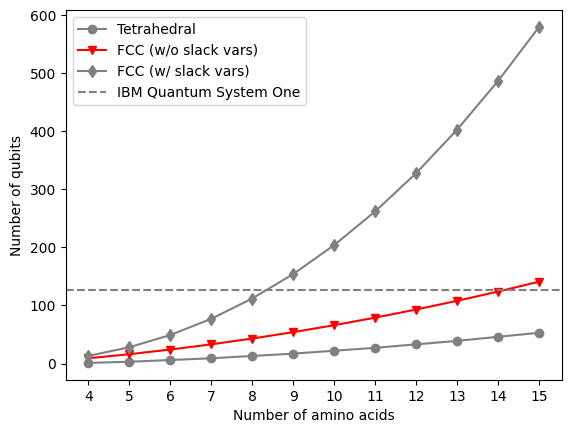

In [33]:
# Plot the number of qubits required for the different lattice approaches as a function of number of amino acids
n = np.arange(4, 16, 1)
plt.plot(n, [tetrahedral(i) for i in n], label="Tetrahedral", marker='o', color='gray')
plt.plot(n, [fcc_no_slack(i) for i in n], label="FCC (w/o slack vars)", marker='v', color='r')
plt.plot(n, [fcc_slack(i) for i in n], label="FCC (w/ slack vars)", marker='d', color='gray')
plt.xticks(n)
plt.xlabel("Number of amino acids")
plt.ylabel("Number of qubits")
plt.axhline(127, color='gray', linestyle='--', label="IBM Quantum System One")
plt.legend()
plt.show()

## Circuit gate scalings

For the following analysis, an approach on FCC lattice *without* using slack variables is assumed. Technically, we currently have two options for such implementation: 
1. using high-degree polynomials to represent the non-overlapping constraints, which are directly added to the Hamiltonian; 
2. introducing Lagrange multipliers to represent the non-overlapping constraints, which can be embedded into the VQE framework without leading to an exponential increase in the number of Hamiltonian terms.

Both approaches lead to the same qubit count as well as the same circuit depth for a given ansatz. Below we will focus on a type of hardware efficient ansatz that we have been testing. We will also assume a fixed number of layers for all problem sizes, which may not be a reasonable assumption in practice.

In [57]:
def transpile_ansatz(
    ansatz_type: str,
    entanglement: str,
    num_layers: int,
    backend: FakeBackendV2 | Backend,
    transpilation_repetitions: int = 10,
) -> tuple[dict, dict]:
    """
    Create a dictionary of circuit depths and ECR depths for the given ansatz and backend.

    Args:
        ansatz_type (str): The ansatz to transpile. Options: "EfficientSU2" or "RealAmplitdues".
        entanglement (str): The entanglement pattern, e.g., "linear" vs. "pairwise".
        backend (FakeBackendV2 | Backend): The backend to transpile the ansatz on.

    Returns:
        tuple[dict, dict]: A tuple of dictionaries containing the circuit depths and ECR depths for the ansatz.
    """
    # Setup empty dictionaries (compare unoptimized and most optimized)
    circ_depths_ansatz: dict[str, list] = {"opt_0": [], "opt_3": []}
    ecr_depths_ansatz: dict[str, list] = {"opt_0": [], "opt_3": []}

    # We will transpile the same circuit multiple times and choose the best result to save due to the stochastic nature of the transpiler
    for n in range(4, 15):
        print(f"num AAs = {n}")
        num_qubits = fcc_no_slack(n)
        print(f"num qubits = {num_qubits}")

        if ansatz_type == "EfficientSU2":
            ansatz = EfficientSU2(
                num_qubits, reps=num_layers, entanglement=entanglement
            )
        elif ansatz_type == "RealAmplitudes":
            ansatz = RealAmplitudes(
                num_qubits, reps=num_layers, entanglement=entanglement
            )
        else:
            raise ValueError("Ansatz not supported yet.")

        opt_0_circ_depth, opt_0_ecr_depth = np.inf, np.inf
        for _ in range(transpilation_repetitions):
            opt_0_circ = transpile(ansatz, backend, optimization_level=0)
            circ_depth = opt_0_circ.depth()
            ecr_depth = opt_0_circ.depth(filter_function=lambda x: x[0].name == "ecr")
            if circ_depth < opt_0_circ_depth:
                opt_0_circ_depth = circ_depth
            if ecr_depth < opt_0_ecr_depth:
                opt_0_ecr_depth = ecr_depth
        circ_depths_ansatz["opt_0"].append(opt_0_circ_depth)
        ecr_depths_ansatz["opt_0"].append(opt_0_ecr_depth)
        print(f"Opt 0: Circ depth = {opt_0_circ_depth}, ECR depth = {opt_0_ecr_depth}")

        opt_3_circ_depth, opt_3_ecr_depth = np.inf, np.inf
        for _ in range(transpilation_repetitions):
            opt_3_circ = transpile(ansatz, backend, optimization_level=3)
            circ_depth = opt_3_circ.depth()
            ecr_depth = opt_3_circ.depth(filter_function=lambda x: x[0].name == "ecr")
            if circ_depth < opt_3_circ_depth:
                opt_3_circ_depth = circ_depth
            if ecr_depth < opt_3_ecr_depth:
                opt_3_ecr_depth = ecr_depth
        circ_depths_ansatz["opt_3"].append(opt_3_circ_depth)
        ecr_depths_ansatz["opt_3"].append(opt_3_ecr_depth)
        print(f"Opt 3: Circ depth = {opt_3_circ_depth}, ECR depth = {opt_3_ecr_depth}")
        print()
    return circ_depths_ansatz, ecr_depths_ansatz

In [58]:
backend = FakeSherbrooke()

# ESU2 with linear entanglement
circ_depths_esu2_linear, ecr_depths_esu2_linear = transpile_ansatz("EfficientSU2", "linear", 2, backend)

# ESU2 with pairwise entanglement
circ_depths_esu2_pairwise, ecr_depths_esu2_pairwise = transpile_ansatz("EfficientSU2", "pairwise", 2, backend)

num AAs = 4
num qubits = 9
Opt 0: Circ depth = 102, ECR depth = 10
Opt 3: Circ depth = 69, ECR depth = 10

num AAs = 5
num qubits = 16
Opt 0: Circ depth = 231, ECR depth = 47
Opt 3: Circ depth = 89, ECR depth = 17

num AAs = 6
num qubits = 24
Opt 0: Circ depth = 475, ECR depth = 102
Opt 3: Circ depth = 137, ECR depth = 25

num AAs = 7
num qubits = 33
Opt 0: Circ depth = 544, ECR depth = 116
Opt 3: Circ depth = 168, ECR depth = 34

num AAs = 8
num qubits = 43
Opt 0: Circ depth = 905, ECR depth = 204
Opt 3: Circ depth = 207, ECR depth = 44

num AAs = 9
num qubits = 54
Opt 0: Circ depth = 1086, ECR depth = 241
Opt 3: Circ depth = 254, ECR depth = 55

num AAs = 10
num qubits = 66
Opt 0: Circ depth = 1348, ECR depth = 304
Opt 3: Circ depth = 298, ECR depth = 67

num AAs = 11
num qubits = 79
Opt 0: Circ depth = 1740, ECR depth = 395
Opt 3: Circ depth = 356, ECR depth = 80

num AAs = 12
num qubits = 93
Opt 0: Circ depth = 1994, ECR depth = 452
Opt 3: Circ depth = 406, ECR depth = 94

num AAs 

In [60]:
# Save the results into a json file
import json
with open("fcc_transpilation_results.json", "w") as f:
    json.dump(
        {
            "circ_depths_esu2_linear": circ_depths_esu2_linear,
            "ecr_depths_esu2_linear": ecr_depths_esu2_linear,
            "circ_depths_esu2_pairwise": circ_depths_esu2_pairwise,
            "ecr_depths_esu2_pairwise": ecr_depths_esu2_pairwise,
        },
        f,
    )

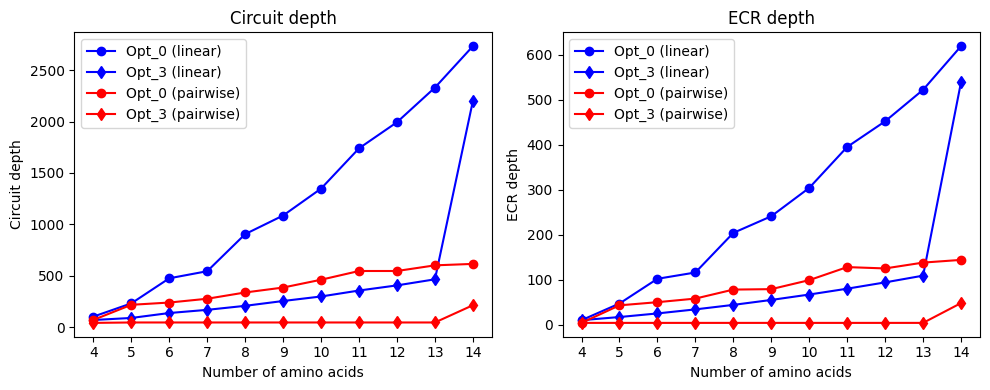

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
num_AAs = range(4, 15)
ax[0].plot(num_AAs, circ_depths_esu2_linear["opt_0"], label="Opt_0 (linear)", marker='o', color='b')
ax[0].plot(num_AAs, circ_depths_esu2_linear["opt_3"], label="Opt_3 (linear)", marker='d', color='b')
ax[0].plot(num_AAs, circ_depths_esu2_pairwise["opt_0"], label="Opt_0 (pairwise)", marker='o', color='r')
ax[0].plot(num_AAs, circ_depths_esu2_pairwise["opt_3"], label="Opt_3 (pairwise)", marker='d', color='r')
ax[0].set_ylabel("Circuit depth")
ax[0].set_xticks(num_AAs)
ax[0].set_xlabel("Number of amino acids")
ax[0].legend()
ax[0].set_title("Circuit depth")

ax[1].plot(num_AAs, ecr_depths_esu2_linear["opt_0"], label="Opt_0 (linear)", marker='o', color='b')
ax[1].plot(num_AAs, ecr_depths_esu2_linear["opt_3"], label="Opt_3 (linear)", marker='d', color='b')
ax[1].plot(num_AAs, ecr_depths_esu2_pairwise["opt_0"], label="Opt_0 (pairwise)", marker='o', color='r')
ax[1].plot(num_AAs, ecr_depths_esu2_pairwise["opt_3"], label="Opt_3 (pairwise)", marker='d', color='r')
ax[1].set_ylabel("ECR depth")
ax[1].set_xticks(num_AAs)
ax[1].set_xlabel("Number of amino acids")
ax[1].legend()
ax[1].set_title("ECR depth")

plt.tight_layout()
plt.show()